---
numbering: false
---

# 1.3: Sets of numbers

There is one set we will see most frequently in this course: the set of **real numbers**, denoted by $\mathbb R$. Before focusing on the real numbers, it helps to see how they fit among the other familiar sets of numbers.

---

## Building the number systems

### Natural numbers: $\mathbb N$

Natural numbers count discrete objects. They answer questions such as:

- How many sensors are installed?
- How many components are in the assembly?
- How many vehicles crossed the bridge?

In these notes, we use the convention

$$
\mathbb N=\{0,1,2,3,\ldots\}.
$$

Thus $0\in\mathbb N$. Other books sometimes begin the natural numbers at $1$.

### Integers: $\mathbb Z$

Counting is not enough when direction or sign matters. The **integers** include the natural numbers and their negative counterparts:

$$
\mathbb Z=\{\ldots,-2,-1,0,1,2,\ldots\}.
$$

For example, an elevation of $-80$ meters can be represented by an integer.


### Rational numbers: $\mathbb Q$

The **rational numbers** are the numbers that can be written as a ratio of integers:

$$
\mathbb Q=
\left\{
\frac{p}{q}:p,q\in\mathbb Z,\ q\ne0
\right\}.
$$

Every integer is rational: for example, $-3=-3/1$. Terminating and repeating decimals are rational too.

### Real numbers: $\mathbb R$

The **real numbers** are all the numbers on the usual number line. They include integers, fractions, and irrational numbers such as $\sqrt2$ and $\pi$.

Real numbers are the natural language for continuously varying quantities such as temperature, voltage, position, velocity, and pressure. A physical measurement is recorded with finite precision, but we usually model the underlying quantity as a real number.

Set-builder notation lets us describe subsets of $\mathbb R$. For example, the positive real numbers form the set

$$
I=\{x:x\in\mathbb R,\ x>0\},
$$

and the closed interval from $0$ to $1$ is

$$
J=\{x:x\in\mathbb R,\ 0\le x\le1\}.
$$


### Complex numbers: $\mathbb C$

Real numbers are not the end of the story. In electrical engineering, an AC impedance might be written as

$$
3+4i,
$$

where $i^2=-1$. This is a **complex number**.

Complex numbers appear naturally in electrical engineering, signal processing, waves, and differential equations. You do not need to master them now. The important point is that linear algebra is not limited to real-valued quantities, even though real numbers will be our main focus.


## How the sets fit together

Each number system above contains the previous one:

$$
\mathbb N
\subseteq
\mathbb Z
\subseteq
\mathbb Q
\subseteq
\mathbb R
\subseteq
\mathbb C.
$$

For instance, $\mathbb N\subseteq\mathbb Z$ says that every natural number is also an integer. It does **not** say that every integer is natural: $-2$ shows why.

The diagram places one example in each newly added region.


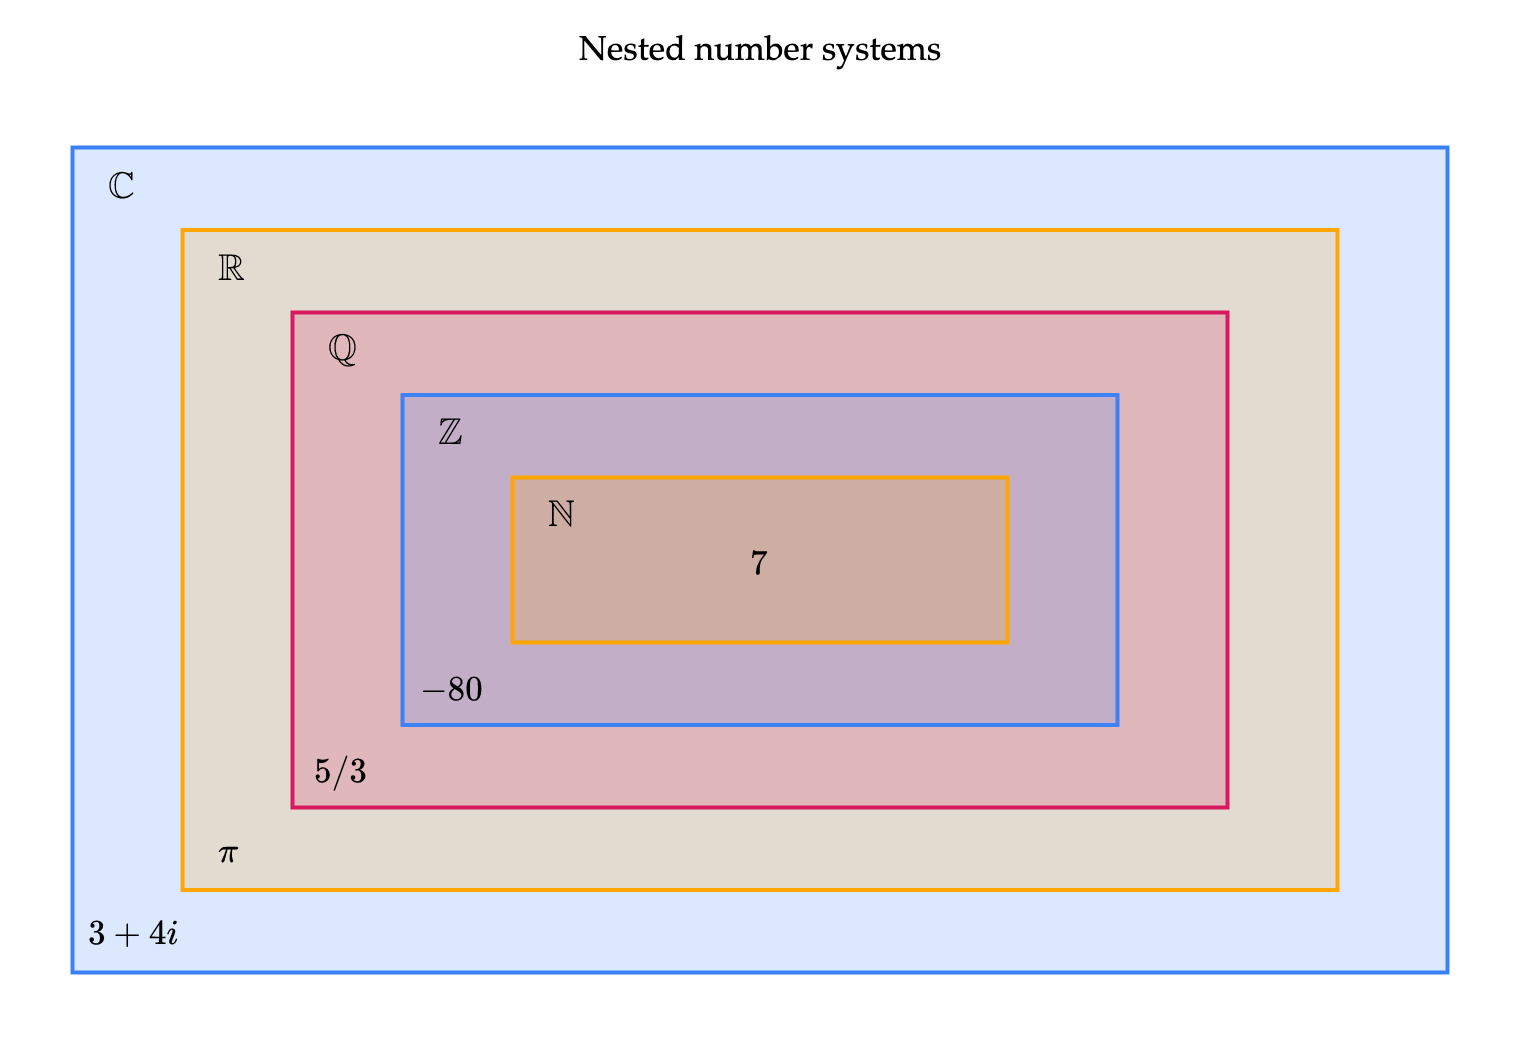

In [1]:
import plotly.graph_objects as go
import plotly.io as pio

fig = go.Figure()
sets = [
    ("$\\mathbb{C}$", 0.0, 0.0, 10.0, 6.0, "rgba(99,110,250,0.12)"),
    ("$\\mathbb{R}$", 0.8, 0.6, 9.2, 5.4, "rgba(239,85,59,0.12)"),
    ("$\\mathbb{Q}$", 1.6, 1.2, 8.4, 4.8, "rgba(0,204,150,0.14)"),
    ("$\\mathbb{Z}$", 2.4, 1.8, 7.6, 4.2, "rgba(171,99,250,0.14)"),
    ("$\\mathbb{N}$", 3.2, 2.4, 6.8, 3.6, "rgba(255,161,90,0.18)"),
]
for label, x0, y0, x1, y1, color in sets:
    fig.add_shape(type="rect", x0=x0, y0=y0, x1=x1, y1=y1,
                  fillcolor=color, line=dict(width=2), layer="below")
    fig.add_annotation(x=x0+0.25, y=y1-0.25, text=label, showarrow=False,
                       xanchor="left", font=dict(size=18))

for x, y, text in [
    (0.45, 0.3, "$3+4i$"), (1.15, 0.88, "$\\pi$"),
    (1.95, 1.48, "$5/3$"), (2.75, 2.08, "$-80$"), (5.0, 3.0, "$7$"),
]:
    fig.add_annotation(x=x, y=y, text=text, showarrow=False, font=dict(size=17))

fig.update_layout(
    title="Nested number systems", width=760, height=520, font_family="Palatino",
    xaxis=dict(range=[-0.2, 10.2], visible=False),
    yaxis=dict(range=[-0.2, 6.2], visible=False, scaleanchor="x"),
    margin=dict(l=20, r=20, t=60, b=20),
)
from pathlib import Path as _PlotPath
import sys as _plot_sys
_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly

_style_plotly(fig, renderer="png")
fig.show(scale=2)


## Activity: choose the smallest natural home

For each quantity, what is the smallest number system that naturally contains it?

| Quantity | Example | Smallest natural home |
|---|---:|---|
| Number of sensors | $7$ | ? |
| Elevation relative to sea level | $-80$ | ? |
| Gear ratio | $5/3$ | ? |
| Measured acceleration | $9.81$ | ? |
| AC impedance | $3+4i$ | ? |

Pause before checking your answers. For each choice, ask what feature forces us to move to a larger set.

:::{dropdown} Check your sorting

| Quantity | Smallest natural home | Why? |
|---|---|---|
| Number of sensors | $\mathbb N$ | It is a nonnegative count. |
| Elevation relative to sea level | $\mathbb Z$ | It may be negative. |
| Gear ratio | $\mathbb Q$ | It is an exact ratio of integers. |
| Measured acceleration | $\mathbb R$ | We model a continuously varying measurement as real-valued. |
| AC impedance | $\mathbb C$ | It may have real and imaginary parts. |

Strictly speaking, the written decimal $9.81$ is rational because $9.81=981/100$. The *measured physical quantity* is naturally modeled as real-valued; the displayed decimal is only a finite-precision record of it. Context matters.
:::

> **Question:** Could the number of sensors also be represented by a real number? Yes. Why, then, is $\mathbb N$ a more informative choice?


---

## Euclidean space

### The real line

The real numbers $\mathbb R$ can be viewed geometrically as the **real line**, where each real number corresponds to one point.


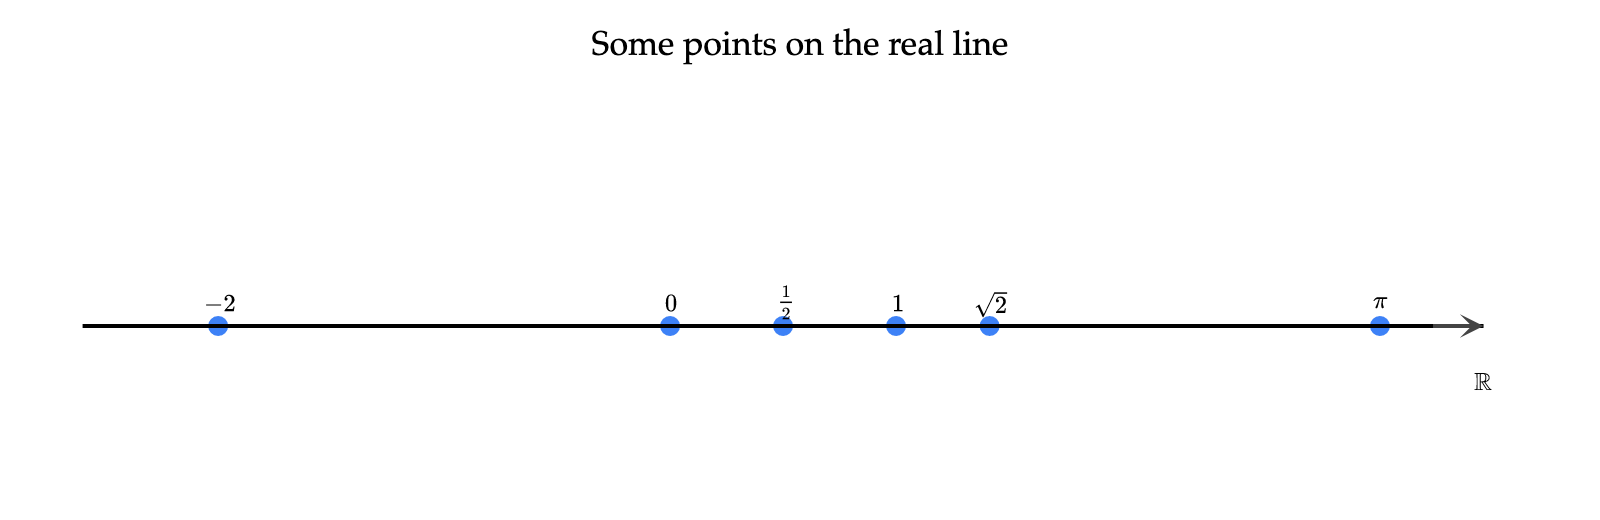

In [2]:
import math
import plotly.graph_objects as go
import plotly.io as pio

values = [-2, 0, 0.5, 1, math.sqrt(2), math.pi]
labels = [r"$-2$", r"$0$", r"$\frac{1}{2}$", r"$1$", r"$\sqrt{2}$", r"$\pi$"]

fig = go.Figure(go.Scatter(
    x=values, y=[0] * len(values), mode="markers+text",
    text=labels, textposition="top center", marker=dict(size=10), hovertemplate="%{x}<extra></extra>",
))
fig.add_shape(type="line", x0=-2.6, x1=3.6, y0=0, y1=0, line=dict(width=2))
fig.add_annotation(x=3.6, y=0, ax=3.35, ay=0, xref="x", yref="y", axref="x", ayref="y", showarrow=True, arrowhead=3)
fig.add_annotation(x=3.62, y=-0.12, text=r"$\mathbb{R}$", showarrow=False)
fig.update_layout(
    title="Some points on the real line", width=800, height=260,
    showlegend=False, font_family="Palatino", margin=dict(l=30, r=30, t=55, b=25),
    xaxis=dict(range=[-2.7, 3.85], visible=False), yaxis=dict(range=[-0.3, 0.45], visible=False),
)
from pathlib import Path as _PlotPath
import sys as _plot_sys
_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly

_style_plotly(fig, renderer="png")
fig.show(scale=2)


### Two-dimensional Euclidean space

The space $\mathbb R^2$ is the set of all ordered pairs of real numbers. In set-builder notation,

$$
\mathbb R^2=\{(x,y):x\in\mathbb R,\ y\in\mathbb R\}.
$$

Equivalently, $\mathbb R^2=\mathbb R\times\mathbb R$. Just as $\mathbb R$ is identified with the real line, $\mathbb R^2$ is identified with the **Euclidean plane**. Its elements are points with an $x$-coordinate and a $y$-coordinate. The term Euclidean is named after [Euclid](https://en.wikipedia.org/wiki/Euclid), an ancient Greek mathematician who was a pivotal figure in geometry.

## Cartesian products

The **Cartesian product** of sets $A$ and $B$ is the set of all ordered pairs whose first entry comes from $A$ and whose second entry comes from $B$:

$$
A\times B=\{(x,y):x\in A,\ y\in B\}.
$$

If $A=\{1,2\}$ and $B=\{x,y,z\}$, then

$$
A\times B
=
\{(1,x),(1,y),(1,z),(2,x),(2,y),(2,z)\}.
$$

Order matters in an ordered pair, so $A\times B$ and $B\times A$ are generally different. Cartesian products will be important in Chapter 1.3, when we use them to construct coordinate spaces.


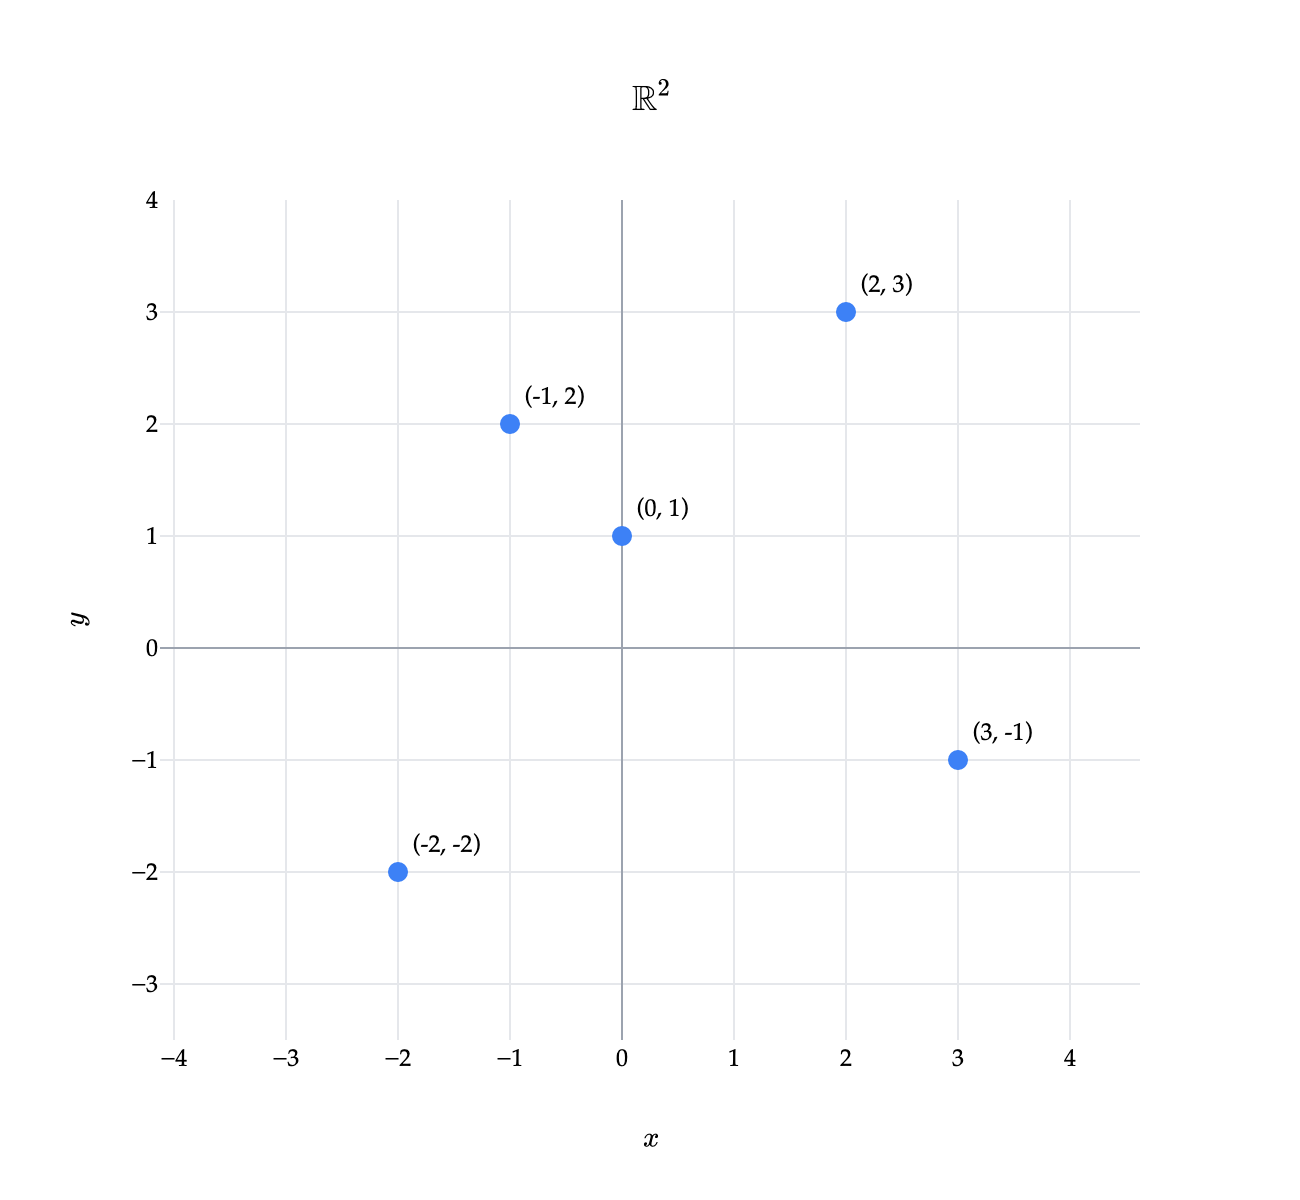

In [3]:
import plotly.graph_objects as go
import plotly.io as pio

points = [(2, 3), (-1, 2), (3, -1), (-2, -2), (0, 1)]
fig = go.Figure(go.Scatter(
    x=[p[0] for p in points], y=[p[1] for p in points], mode="markers+text",
    text=[f"({x}, {y})" for x, y in points], textposition="top right",
    marker=dict(size=10), hovertemplate="(%{x}, %{y})<extra></extra>",
))
fig.update_layout(
    title=r"Points in $\mathbb{R}^2$", width=650, height=600,
    xaxis_title="$x$", yaxis_title="$y$", showlegend=False, font_family="Palatino",
)
fig.update_xaxes(range=[-3.5, 4], dtick=1, zeroline=True, scaleanchor="y")
fig.update_yaxes(range=[-3.5, 4], dtick=1, zeroline=True)
from pathlib import Path as _PlotPath
import sys as _plot_sys
_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly

_style_plotly(fig, renderer="png")
fig.show(scale=2)


The order of the two coordinates matters. The points $(2,3)$ and $(3,2)$ are different elements of $\mathbb R^2$. This is unlike sets, where order does not matter: $\{2,3\}=\{3,2\}$.


### Three-dimensional Euclidean space

The space $\mathbb R^3$ is the set of all ordered triples of real numbers:

$$
\mathbb R^3=\{(x,y,z):x,y,z\in\mathbb R\}.
$$

We identify its elements with points in three-dimensional Euclidean space.


In [4]:
import plotly.graph_objects as go
import plotly.io as pio

points = [(1, 2, 3), (-2, 1, 2), (3, -1, 1), (-1, -2, -1), (0, 2, -2)]
fig = go.Figure(go.Scatter3d(
    x=[p[0] for p in points], y=[p[1] for p in points], z=[p[2] for p in points],
    mode="markers+text", text=[f"({x}, {y}, {z})" for x, y, z in points],
    textposition="top right", marker=dict(size=5),
    hovertemplate="(%{x}, %{y}, %{z})<extra></extra>",
))
axis = dict(range=[-3, 4], dtick=1)
fig.update_layout(
    title=r"Points in $\mathbb{R}^3$", width=720, height=620,
    showlegend=False, font_family="Palatino",
    scene=dict(xaxis=axis, yaxis=axis, zaxis=axis, aspectmode="cube"),
)
from pathlib import Path as _PlotPath
import sys as _plot_sys
_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly

_style_plotly(fig, renderer="plotly_mimetype")
fig.show()


### $n$-dimensional Euclidean space

We can generalize beyond two and three dimensions. The **$n$-dimensional Euclidean space** is the set of all ordered $n$-tuples of real numbers:

$$
\mathbb R^n
=
\{(x_1,\ldots,x_n):x_1,\ldots,x_n\in\mathbb R\}.
$$

Equivalently, $\mathbb R^n$ is the Cartesian product of $\mathbb R$ with itself $n$ times. The exponent tells us the number of real-number slots; it is not ordinary exponentiation.

Although spaces beyond three dimensions are hard to draw, they are useful in applications:

- a robot configuration may be represented by several joint angles;
- a fluid network may have many flow measurements;
- an audio signal may contain thousands or millions of samples;
- PageRank may associate one score with every webpage.

Once we collect several numbers into an ordered object, we arrive at one of the central objects of linear algebra: the **vector**.
